# Demo 4: Python and SQL Integration

In this notebook, we'll explore how to combine Python's data analysis capabilities with SQL for powerful data processing. We'll cover:

1. SQL to Pandas DataFrame conversion
2. Data visualization with SQL results
3. Advanced data analysis
4. Machine learning preparation

## Setup

First, let's set up our environment with necessary packages:

In [1]:
%pip install jupysql duckdb pandas polars matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
%load_ext sql

# Configure SQL magic for better output
%config SqlMagic.autopandas = True
%config SqlMagic.autocommit=True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False

# Connect to DuckDB
# Execute SQL queries with pandas' `read_sql` function
# results_df = pd.read_sql("SELECT * FROM demographics LIMIT 5", engine)
engine = create_engine('duckdb:///:memory:')

# Use this engine for jupysql
%sql engine

# NOTE: memory db's are not shared between connections
# If using only jupysql, you can use the following:
# %sql duckdb:///:memory:

## Load Data

Let's load our NHANES data directly from CSV files:

In [3]:
%%sql
-- Clean up any existing tables
DROP TABLE IF EXISTS questionnaire;
DROP TABLE IF EXISTS laboratory;
DROP TABLE IF EXISTS examination;
DROP TABLE IF EXISTS demographics;

-- Load demographics
CREATE TABLE demographics AS
SELECT * FROM read_csv_auto('data/demographics.csv');

-- Load examination
CREATE TABLE examination AS
SELECT * FROM read_csv_auto('data/examination.csv');

-- Load laboratory
CREATE TABLE laboratory AS
SELECT * FROM read_csv_auto('data/labs.csv');

-- Load questionnaire
CREATE TABLE questionnaire AS
SELECT * FROM read_csv_auto('data/questionnaire.csv');

,Success


## SQL to Pandas DataFrame

Let's explore different ways to get SQL results into pandas:

In [4]:
# With autopandas, the result is automatically converted to a pandas DataFrame
df1 = %sql SELECT * FROM demographics limit 1
%sql df2 << SELECT * FROM demographics limit 1

display(df1)
display(df2)

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557,8,2,1,69,<NA>,4,4,1,<NA>,...,3,4,<NA>,13281.237386,13481.042095,1,112,4,4,0.84


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557,8,2,1,69,<NA>,4,4,1,<NA>,...,3,4,<NA>,13281.237386,13481.042095,1,112,4,4,0.84


In [5]:
# Use the --persist flag to persist the result in the database
%sql --persist df1

# And then query it directly with SQL
%sql SELECT * FROM df1

Success! Persisted df1 to the database.

,index,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,0,73557,8,2,1,69,<NA>,4,4,1,...,3,4,<NA>,13281.237386,13481.042095,1,112,4,4,0.84


In [6]:
# Using SQLAlchemy engine to talk to DuckDB
bmi_df = pd.read_sql("""
    SELECT d.SEQN, d.RIDAGEYR, d.RIAGENDR, e.BMXBMI
    FROM demographics d
    JOIN examination e ON d.SEQN = e.SEQN
""", engine)

bmi_df.head()

,SEQN,RIDAGEYR,RIAGENDR,BMXBMI
0,73557,69,1,26.7
1,73558,54,1,28.6
2,73559,72,1,28.9
3,73560,9,1,17.1
4,73561,73,2,19.7


## Data Visualization

Let's create some visualizations using SQL results:

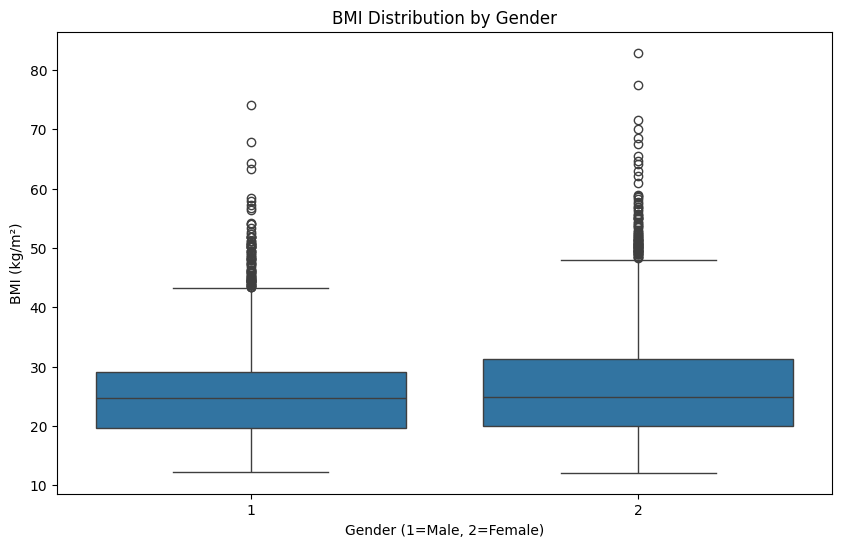

In [7]:
# Get data for visualization
health_df = pd.read_sql("""
    SELECT 
        d.SEQN, d.RIDAGEYR, d.RIAGENDR, d.RIDRETH1,
        e.BMXBMI, l.LBXTC,
        q.DIQ010
    FROM demographics d
    LEFT JOIN examination e ON d.SEQN = e.SEQN
    LEFT JOIN laboratory l ON d.SEQN = l.SEQN
    LEFT JOIN questionnaire q ON d.SEQN = q.SEQN
""", engine)

# Visualize BMI distribution by gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='RIAGENDR', y='BMXBMI', data=health_df)
plt.title('BMI Distribution by Gender')
plt.xlabel('Gender (1=Male, 2=Female)')
plt.ylabel('BMI (kg/m²)')
plt.show()

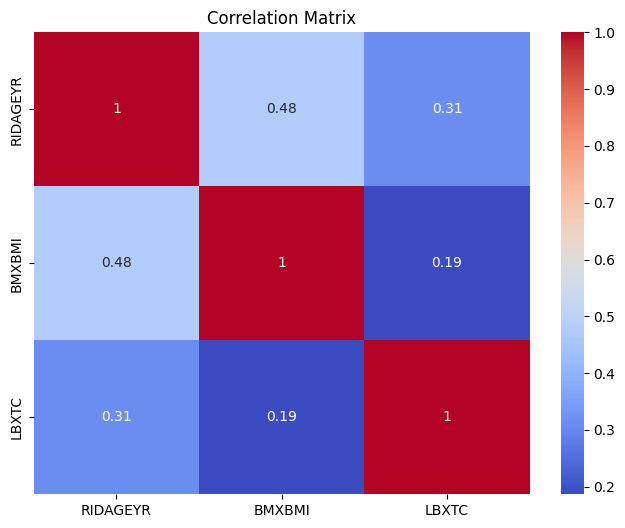

In [8]:
# Correlation analysis
correlation_df = health_df[['RIDAGEYR', 'BMXBMI', 'LBXTC']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Advanced Analysis

Let's perform more complex analysis combining SQL and Python:

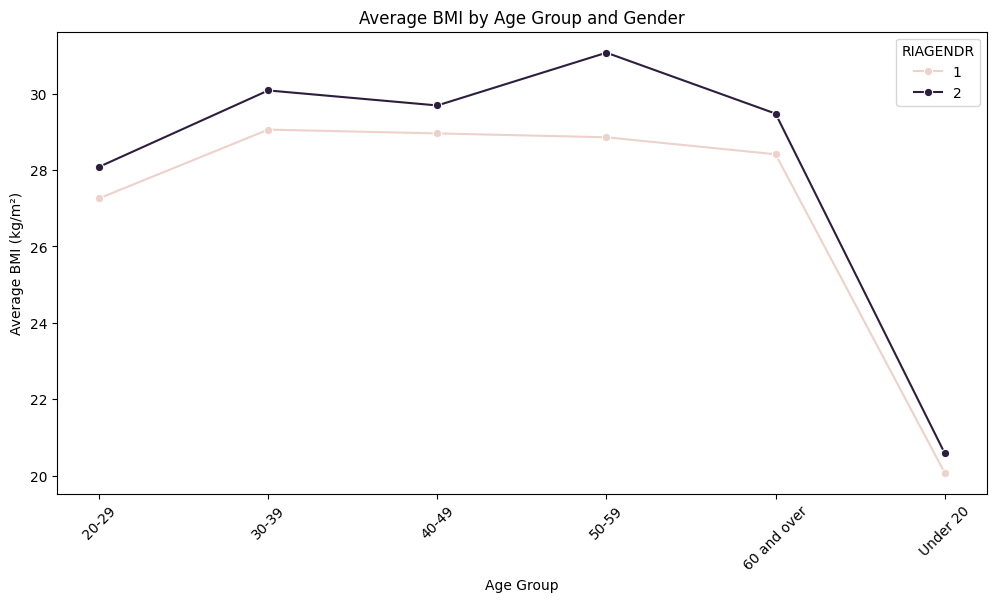

In [9]:
# Get age-specific statistics using SQL
age_stats = pd.read_sql("""
    WITH age_groups AS (
        SELECT 
            CASE
                WHEN RIDAGEYR < 20 THEN 'Under 20'
                WHEN RIDAGEYR < 30 THEN '20-29'
                WHEN RIDAGEYR < 40 THEN '30-39'
                WHEN RIDAGEYR < 50 THEN '40-49'
                WHEN RIDAGEYR < 60 THEN '50-59'
                ELSE '60 and over'
            END AS age_group,
            d.SEQN, d.RIAGENDR, e.BMXBMI, l.LBXTC
        FROM demographics d
        LEFT JOIN examination e ON d.SEQN = e.SEQN
        LEFT JOIN laboratory l ON d.SEQN = l.SEQN
    )
    SELECT 
        age_group,
        RIAGENDR,
        COUNT(*) AS count,
        AVG(BMXBMI) AS avg_bmi,
        AVG(LBXTC) AS avg_cholesterol
    FROM age_groups
    GROUP BY age_group, RIAGENDR
    ORDER BY age_group, RIAGENDR
""", engine)

# Visualize age trends
plt.figure(figsize=(12, 6))
sns.lineplot(x='age_group', y='avg_bmi', hue='RIAGENDR', data=age_stats, marker='o')
plt.title('Average BMI by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Average BMI (kg/m²)')
plt.xticks(rotation=45)
plt.show()

## Machine Learning Preparation

Let's prepare data for machine learning:

In [10]:
# Get data for machine learning
ml_data = pd.read_sql("""
    SELECT 
        d.RIDAGEYR,
        d.RIAGENDR,
        d.RIDRETH1,
        e.BMXBMI,
        l.LBXTC,
        q.DIQ010,
        CASE
            WHEN l.LBXTC > 200 THEN 1
            ELSE 0
        END AS high_cholesterol
    FROM demographics d
    LEFT JOIN examination e ON d.SEQN = e.SEQN
    LEFT JOIN laboratory l ON d.SEQN = l.SEQN
    LEFT JOIN questionnaire q ON d.SEQN = q.SEQN
    WHERE l.LBXTC IS NOT NULL
""", engine)

# Basic feature engineering
ml_data['age_squared'] = ml_data['RIDAGEYR'] ** 2
ml_data['bmi_category'] = pd.cut(ml_data['BMXBMI'], 
                                bins=[0, 18.5, 25, 30, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# One-hot encoding
ml_data_encoded = pd.get_dummies(ml_data, columns=['RIAGENDR', 'RIDRETH1', 'bmi_category', 'DIQ010'])

ml_data_encoded.head()

,RIDAGEYR,BMXBMI,LBXTC,high_cholesterol,age_squared,RIAGENDR_1,RIAGENDR_2,RIDRETH1_1,RIDRETH1_2,RIDRETH1_3,RIDRETH1_4,RIDRETH1_5,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,DIQ010_1,DIQ010_2,DIQ010_3,DIQ010_9
0,69,26.7,167,0,4761,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False
1,54,28.6,170,0,2916,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False
2,72,28.9,126,0,5184,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False
3,9,17.1,168,0,81,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False
4,73,19.7,201,1,5329,False,True,False,False,True,False,False,False,True,False,False,False,True,False,False


## Practice

Try these exercises:
1. Create a visualization showing the relationship between BMI and cholesterol levels by gender
2. Build a correlation matrix for all numeric variables
3. Create age-specific box plots for BMI distribution
4. Prepare a dataset for predicting high cholesterol using additional features